# SAM 3 Image Segmentation with OpenVINO

[SAM 3](https://github.com/facebookresearch/sam3) is Meta's unified vision-language model that supports:
- **Text-prompted segmentation**: Segment objects by describing them in natural language
- **Box-prompted segmentation**: Use bounding boxes as visual prompts (positive/negative)
- **Point-prompted segmentation** (SAM1 task): Click foreground/background points
- **Video object tracking** (SAM2 task): Track objects across video frames

This notebook demonstrates how to convert SAM 3 models to OpenVINO IR format and run inference using OpenVINO.

The model is decomposed into multiple sub-models for efficient conversion:
1. **Image Encoder** — ViT backbone with FPN neck
2. **Text Encoder** — Text transformer for language understanding
3. **Transformer Encoder** — Multi-level feature fusion with text cross-attention
4. **Decoder + Scoring** — Object query decoding with box refinement and dot-product scoring (merged)
5. **Segmentation Head** — Pixel decoder + mask prediction
6. **SAM2 Prompt Encoder** — Point/box prompt encoding (for SAM1 task)
7. **SAM2 Mask Decoder** — Mask prediction from prompts (for SAM1 task)

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Load PyTorch Model](#Load-PyTorch-Model)
- [PyTorch Baseline Demos](#PyTorch-Baseline-Demos)
- [Convert Models to OpenVINO](#Convert-Models-to-OpenVINO)
- [OpenVINO Image Segmentation](#OpenVINO-Image-Segmentation)
- [OpenVINO SAM1 Task (Point/Box Prompting)](#OpenVINO-SAM1-Task)
- [Testing & Verification](#Testing-and-Verification)
- [Performance Comparison](#Performance-Comparison)- [Interactive Demo](#Interactive-Demo)


## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [ ]:
import platform
import requests
from pathlib import Path

if not Path("notebook_utils.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py")
    open("notebook_utils.py", "w").write(r.text)

if not Path("pip_helper.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/pip_helper.py",
    )
    open("pip_helper.py", "w").write(r.text)

from pip_helper import pip_install

pip_install(
    "-q",
    "torch>=2.4",
    "torchvision",
    "openvino>=2024.4",
    "Pillow",
    "matplotlib",
    "numpy<2",
    "--extra-index-url",
    "https://download.pytorch.org/whl/cpu",
)
pip_install(
    "-q",
    "timm>=1.0.17",
    "ftfy==6.1.1",
    "regex",
    "iopath>=0.1.10",
    "scikit-image",
    "pycocotools",
    "gradio>=4.19",
    "modelscope",
)

In [2]:
import subprocess
import sys
import types
from pathlib import Path

# ---------------------------------------------------------------------------
# 1. Clone SAM3 source code
# ---------------------------------------------------------------------------
sam3_root = Path("sam3")
if not sam3_root.exists():
    print("Cloning SAM3 repository...")
    subprocess.run(
        ["git", "clone", "https://github.com/facebookresearch/sam3.git", str(sam3_root)],
        check=True,
    )
    print("SAM3 cloned.")
else:
    print(f"SAM3 source already exists at {sam3_root}")

# ---------------------------------------------------------------------------
# 2. Download SAM3 model weights from ModelScope
# ---------------------------------------------------------------------------
model_dir = Path("sam3_model")
checkpoint = model_dir / "sam3.pt"
if not checkpoint.exists():
    print("Downloading SAM3 weights from ModelScope (facebook/sam3)...")
    try:
        from modelscope import snapshot_download
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "modelscope"], check=True)
        from modelscope import snapshot_download
    snapshot_download("facebook/sam3", local_dir=str(model_dir))
    print(f"Weights downloaded to {model_dir}")
else:
    print(f"SAM3 checkpoint already exists at {checkpoint}")

# ---------------------------------------------------------------------------
# 3. Patch SAM3 source for CPU-only inference (no CUDA).
#    All replacements are single-line — safe in any Python/JSON environment.
#    Idempotent: re-running after re-download always works.
# ---------------------------------------------------------------------------
def _patch_file(path, replacements):
    p = Path(path)
    text = p.read_text(encoding="utf-8")
    for old, new in replacements:
        text = text.replace(old, new)
    p.write_text(text, encoding="utf-8")

sam3_pkg = sam3_root / "sam3"

# position_encoding.py — precompute tensors on cpu
_patch_file(sam3_pkg / "model" / "position_encoding.py", [
    ('device="cuda")', 'device="cpu")'),
])

# decoder.py — autocast device + BoxRPB coord cache
_patch_file(sam3_pkg / "model" / "decoder.py", [
    ('device_type="cuda", enabled=False', 'device_type="cpu", enabled=False'),
    ('feat_size, feat_size, device="cuda"', 'feat_size, feat_size, device="cpu"'),
])

# geometry_encoders.py, sam3_tracker_base.py, sam3_video_inference.py
# pin_memory() requires a CUDA device; simply remove it (to() still works on CPU)
for rel_path in [
    "model/geometry_encoders.py",
    "model/sam3_tracker_base.py",
    "model/sam3_video_inference.py",
]:
    _patch_file(sam3_pkg / rel_path, [
        (".pin_memory().to(", ".to("),
    ])

# sam3_video_inference.py — remove @autocast(cuda) decorators
_patch_file(sam3_pkg / "model" / "sam3_video_inference.py", [
    ('@torch.autocast(device_type="cuda", dtype=torch.bfloat16)', '# autocast disabled on CPU'),
])

# sam3_tracking_predictor.py — replace CUDA bf16 context with CPU no-op
_patch_file(sam3_pkg / "model" / "sam3_tracking_predictor.py", [
    ('torch.autocast(device_type="cuda", dtype=torch.bfloat16)',
     'torch.autocast(device_type="cpu", enabled=False)'),
])

print("CPU patches applied.")

# ---------------------------------------------------------------------------
# 4. Mock triton (CUDA-only, not needed for CPU/OpenVINO)
# ---------------------------------------------------------------------------
if "triton" not in sys.modules:
    triton = types.ModuleType("triton")
    tl = types.ModuleType("triton.language")
    class _ConstExpr: pass
    tl.constexpr = _ConstExpr
    def _jit(*a, **kw):
        if len(a) == 1 and callable(a[0]): return a[0]
        def w(f): return f
        return w
    triton.jit = _jit
    triton.language = tl
    triton.cdiv = lambda a, b: (a + b - 1) // b
    sys.modules["triton"] = triton
    sys.modules["triton.language"] = tl

# Add sam3 package to path
sys.path.insert(0, str(sam3_root))
print("Environment ready.")


SAM3 source already exists at sam3
SAM3 checkpoint already exists at sam3_model\sam3.pt
CPU patches applied.
Environment ready.


In [3]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

import openvino as ov

# Suppress unnecessary warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

## Load PyTorch Model
[back to top ⬆️](#Table-of-contents:)

In [4]:
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

bpe_path = str(sam3_root / "sam3" / "assets" / "bpe_simple_vocab_16e6.txt.gz")
checkpoint_path = str(Path("sam3_model") / "sam3.pt")

model = build_sam3_image_model(
    bpe_path=bpe_path,
    device="cpu",
    eval_mode=True,
    checkpoint_path=checkpoint_path,
    load_from_HF=False,
    enable_inst_interactivity=True,
    compile=False,
)
print(f"Model loaded on CPU with {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M parameters")

Model loaded on CPU with 860.1M parameters


Image size: 1280x720


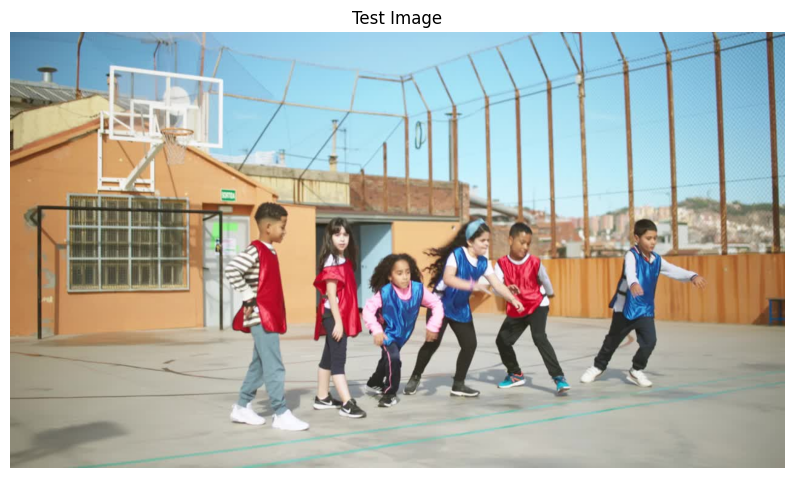

In [5]:
# Load test image
image_path = str(sam3_root / "assets" / "images" / "test_image.jpg")
image = Image.open(image_path)
width, height = image.size
print(f"Image size: {width}x{height}")

plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Test Image")
plt.show()

## PyTorch Baseline Demos
[back to top ⬆️](#Table-of-contents:)

Run the original SAM3 model to establish baselines for comparison with OpenVINO results.

### Text prompt: "shoe"

found 12 object(s)
Found 12 object(s) with scores: [0.8131348490715027, 0.8063616156578064, 0.660047173500061, 0.8072618246078491, 0.8041028380393982, 0.8124598264694214, 0.7910696864128113, 0.7879394292831421, 0.7882112860679626, 0.7865720987319946, 0.8111516237258911, 0.8037744164466858]


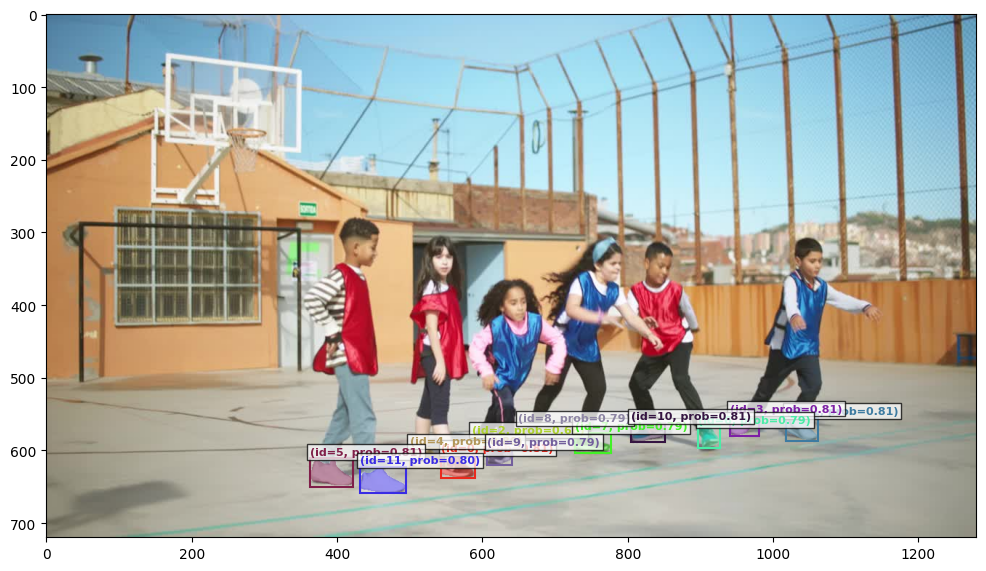

In [6]:
processor = Sam3Processor(model, device="cpu", confidence_threshold=0.5)
inference_state = processor.set_image(image)

processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="shoe")

pt_text_masks = inference_state["masks"].clone()
pt_text_scores = inference_state["scores"].clone()

img0 = Image.open(image_path)
plot_results(img0, inference_state)
print(f"Found {len(pt_text_masks)} object(s) with scores: {pt_text_scores.tolist()}")

### Single box prompt

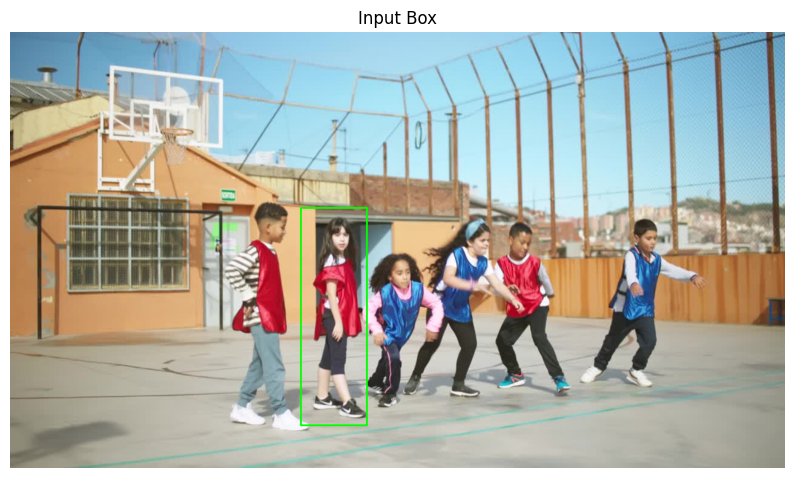

found 6 object(s)


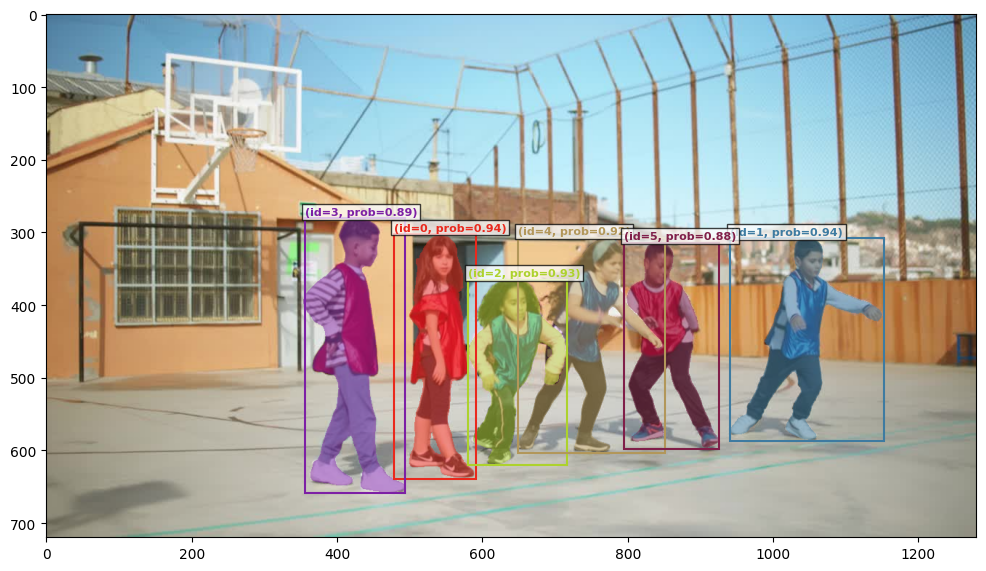

In [7]:
# Box in (x, y, w, h) format, where (x, y) is the top-left corner
box_input_xywh = torch.tensor([480.0, 290.0, 110.0, 360.0]).view(-1, 4)
box_input_cxcywh = box_xywh_to_cxcywh(box_input_xywh)
norm_box_cxcywh = normalize_bbox(box_input_cxcywh, width, height).flatten().tolist()

processor.reset_all_prompts(inference_state)
inference_state = processor.add_geometric_prompt(
    state=inference_state, box=norm_box_cxcywh, label=True
)

pt_box_masks = inference_state["masks"].clone()

img0 = Image.open(image_path)
image_with_box = draw_box_on_image(img0, box_input_xywh.flatten().tolist())
plt.figure(figsize=(10, 8))
plt.imshow(image_with_box)
plt.axis("off")
plt.title("Input Box")
plt.show()

img0 = Image.open(image_path)
plot_results(img0, inference_state)

### Multi-box prompting (positive and negative)

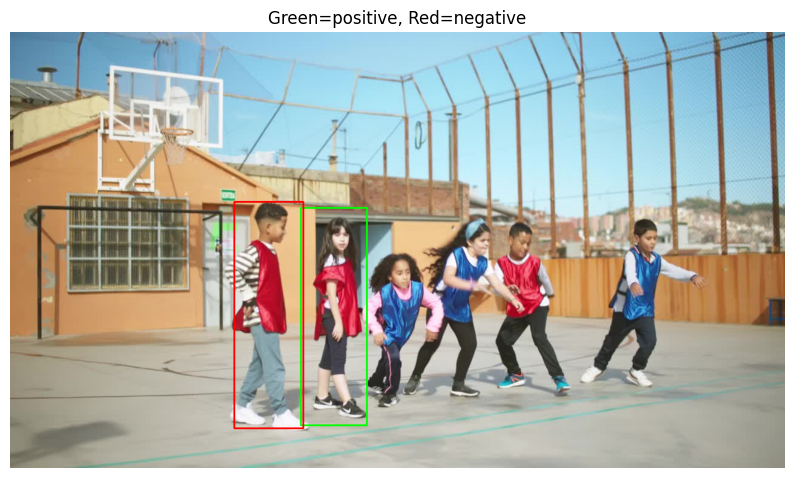

found 5 object(s)


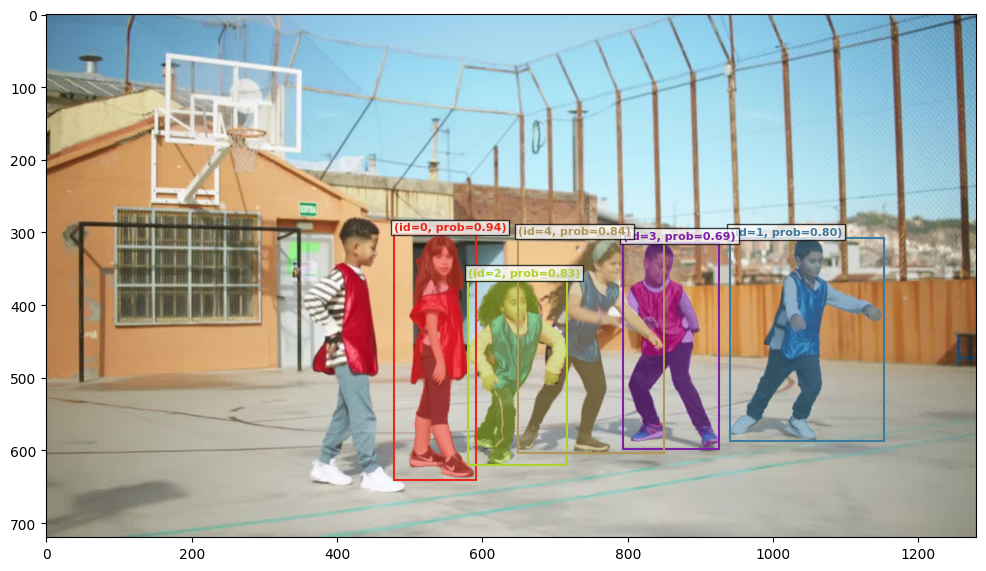

In [8]:
box_input_xywh_list = [[480.0, 290.0, 110.0, 360.0], [370.0, 280.0, 115.0, 375.0]]
box_input_cxcywh = box_xywh_to_cxcywh(torch.tensor(box_input_xywh_list).view(-1, 4))
norm_boxes_cxcywh = normalize_bbox(box_input_cxcywh, width, height).tolist()
box_labels = [True, False]

processor.reset_all_prompts(inference_state)
for box, label in zip(norm_boxes_cxcywh, box_labels):
    inference_state = processor.add_geometric_prompt(
        state=inference_state, box=box, label=label
    )

pt_multibox_masks = inference_state["masks"].clone()

# Visualize boxes
img0 = Image.open(image_path)
for i in range(len(box_input_xywh_list)):
    color = (0, 255, 0) if box_labels[i] else (255, 0, 0)
    img0 = draw_box_on_image(img0, box_input_xywh_list[i], color)
plt.figure(figsize=(10, 8))
plt.imshow(img0)
plt.axis("off")
plt.title("Green=positive, Red=negative")
plt.show()

img0 = Image.open(image_path)
plot_results(img0, inference_state)

## Convert Models to OpenVINO
[back to top ⬆️](#Table-of-contents:)

We decompose the SAM3 model into separate sub-models for OpenVINO conversion.
Each sub-model is wrapped in a dedicated class that produces traceable forward passes.

In [9]:
from ov_sam3_helper import (
    patch_vit_rope,
    patch_tracker_rope,
    Sam3ImageEncoderModel,
    Sam3TextEncoderModel,
    Sam3TransformerEncoderModel,
    Sam3DecoderWithScoringModel,
    Sam3GeometryEncoderModel,
    Sam3SegmentationHeadModel,
    Sam3SAM2PromptEncoderModel,
    Sam3SAM2MaskDecoderModel,
    convert_and_save_model,
)

ov_model_dir = Path("ov_models")
ov_model_dir.mkdir(exist_ok=True)

### Image Encoder

The image encoder uses a ViT backbone with Rotary Position Encoding (RoPE).
We must replace the complex tensor-based RoPE with matrix multiplication before conversion.

In [10]:
# Patch RoPE to use matrix multiplication (OpenVINO doesn't support complex tensors)
patch_vit_rope(model.backbone.vision_backbone.trunk)

image_encoder_wrapper = Sam3ImageEncoderModel(
    neck=model.backbone.vision_backbone,
    scalp=model.backbone.scalp,
)

ov_image_encoder_path = ov_model_dir / "image_encoder.xml"
ov_image_encoder_model = convert_and_save_model(
    wrapper_model=image_encoder_wrapper,
    example_input=torch.zeros(1, 3, 1008, 1008),
    save_path=str(ov_image_encoder_path),
    model_name="Image Encoder",
)

  Converting Image Encoder...
  Saved Image Encoder to ov_models\image_encoder.xml


### Text Encoder

In [11]:
text_encoder_wrapper = Sam3TextEncoderModel(
    text_encoder=model.backbone.language_backbone,
)

ov_text_encoder_path = ov_model_dir / "text_encoder.xml"
ov_text_encoder_model = convert_and_save_model(
    wrapper_model=text_encoder_wrapper,
    example_input=torch.zeros(1, 32, dtype=torch.long),
    save_path=str(ov_text_encoder_path),
    model_name="Text Encoder",
)

  Converting Text Encoder...
  Saved Text Encoder to ov_models\text_encoder.xml


### Transformer Encoder

The transformer encoder fuses image features with text prompt embeddings through cross-attention.

In [12]:
encoder_wrapper = Sam3TransformerEncoderModel(
    encoder=model.transformer.encoder,
    feat_h=72,
    feat_w=72,
)

# Dummy inputs: seq-first (HW, B, C) where H=W=72
seq_len = 72 * 72  # 5184
dummy_img_feat = torch.randn(seq_len, 1, 256)
dummy_img_pos = torch.randn(seq_len, 1, 256)
# Prompt: (seq_len, B, C) - text prompt features
dummy_prompt = torch.randn(10, 1, 256)
dummy_prompt_mask = torch.zeros(1, 10, dtype=torch.bool)

ov_encoder_path = ov_model_dir / "transformer_encoder.xml"
ov_encoder_model = convert_and_save_model(
    wrapper_model=encoder_wrapper,
    example_input=(dummy_img_feat, dummy_img_pos, dummy_prompt, dummy_prompt_mask),
    save_path=str(ov_encoder_path),
    model_name="Transformer Encoder",
)

  Converting Transformer Encoder...
  Saved Transformer Encoder to ov_models\transformer_encoder.xml


### Transformer Decoder + Scoring (Merged)

The decoder and scoring head are merged into a single OV model, eliminating one inference call and the intermediate transpose operation.

In [13]:
decoder_scoring_wrapper = Sam3DecoderWithScoringModel(
    decoder=model.transformer.decoder,
    dot_prod_scoring=model.dot_prod_scoring,
    bbox_embed=model.transformer.decoder.bbox_embed,
    decoder_norm=model.transformer.decoder.norm,
)

# Decoder inputs
seq_len = 72 * 72  # 5184
dummy_memory = torch.randn(seq_len, 1, 256)
dummy_pos_embed = torch.randn(seq_len, 1, 256)
dummy_memory_mask = torch.zeros(1)
dummy_level_start = torch.tensor([0], dtype=torch.long)
dummy_spatial = torch.tensor([[72, 72]], dtype=torch.long)
dummy_valid_ratios = torch.ones(1, 1, 2)
dummy_prompt_dec = torch.randn(10, 1, 256)
dummy_prompt_mask_dec = torch.zeros(1, 10, dtype=torch.bool)

# Delete existing file to force re-conversion (now includes bbox_embed + decoder_norm)
import os
dec_path = ov_model_dir / "decoder_scoring.xml"
if dec_path.exists():
    dec_path.unlink()
    for ext in [".bin"]:
        p = dec_path.with_suffix(ext)
        if p.exists():
            p.unlink()

ov_decoder_scoring_path = ov_model_dir / "decoder_scoring.xml"
ov_decoder_scoring_model = convert_and_save_model(
    wrapper_model=decoder_scoring_wrapper,
    example_input=(
        dummy_memory, dummy_pos_embed, dummy_memory_mask,
        dummy_level_start, dummy_spatial, dummy_valid_ratios,
        dummy_prompt_dec, dummy_prompt_mask_dec,
    ),
    save_path=str(ov_decoder_scoring_path),
    model_name="Decoder + Scoring + BoxRefinement",
)

# Geometry encoder conversion (max_boxes=10 padded inputs)
MAX_BOXES = 10
geo_wrapper = Sam3GeometryEncoderModel(geometry_encoder=model.geometry_encoder)

dummy_box_emb = torch.zeros(MAX_BOXES, 1, 4)        # padded boxes (cxcywh [0,1])
dummy_box_mask = torch.ones(1, MAX_BOXES, dtype=torch.bool)  # all padded
dummy_box_labels = torch.ones(MAX_BOXES, 1, dtype=torch.long)
dummy_img_feat = torch.randn(72 * 72, 1, 256)       # (HW, B, C)
dummy_img_pos  = torch.randn(72 * 72, 1, 256)

ov_geometry_encoder_path = ov_model_dir / "geometry_encoder.xml"
ov_geometry_encoder_model = convert_and_save_model(
    wrapper_model=geo_wrapper,
    example_input=(
        dummy_box_emb, dummy_box_mask, dummy_box_labels,
        dummy_img_feat, dummy_img_pos,
    ),
    save_path=str(ov_geometry_encoder_path),
    model_name="Geometry Encoder",
)


  Converting Decoder + Scoring + BoxRefinement...
  Saved Decoder + Scoring + BoxRefinement to ov_models\decoder_scoring.xml
  Converting Geometry Encoder...
  Saved Geometry Encoder to ov_models\geometry_encoder.xml


### Segmentation Head

The segmentation head includes a pixel decoder (FPN upsampling), instance segmentation head, and mask predictor.

In [14]:
num_queries = model.transformer.decoder.num_queries
num_layers = len(model.transformer.decoder.layers)

seg_wrapper = Sam3SegmentationHeadModel(
    seg_head=model.segmentation_head,
)

# FPN features at 3 resolution levels (after scalp=1)
seq_len = 72 * 72  # 5184
dummy_fpn0 = torch.randn(1, 256, 288, 288)
dummy_fpn1 = torch.randn(1, 256, 144, 144)
dummy_fpn2 = torch.randn(1, 256, 72, 72)
dummy_obj_queries = torch.randn(1, num_queries, 256)
dummy_enc_states = torch.randn(seq_len, 1, 256)
dummy_prompt_seg = torch.randn(10, 1, 256)
dummy_mask_seg = torch.zeros(1, 10, dtype=torch.bool)

ov_seg_path = ov_model_dir / "segmentation_head.xml"
ov_seg_model = convert_and_save_model(
    wrapper_model=seg_wrapper,
    example_input=(
        dummy_fpn0, dummy_fpn1, dummy_fpn2,
        dummy_obj_queries, dummy_enc_states,
        dummy_prompt_seg, dummy_mask_seg,
    ),
    save_path=str(ov_seg_path),
    model_name="Segmentation Head",
)

  Converting Segmentation Head...
  Saved Segmentation Head to ov_models\segmentation_head.xml


### SAM2-Style Prompt Encoder (for SAM1 Task)

Used for point/box prompting with the interactive predictor.

In [15]:
if model.inst_interactive_predictor is not None:
    tracker_model = model.inst_interactive_predictor.model
    
    prompt_enc_wrapper = Sam3SAM2PromptEncoderModel(
        prompt_encoder=tracker_model.sam_prompt_encoder,
        image_size=tracker_model.image_size,
    )

    dummy_coords = torch.zeros(1, 3, 2)  # (B, N_points, 2)
    dummy_labels = torch.ones(1, 3, dtype=torch.int32)  # (B, N_points)
    dummy_has_box = torch.tensor(0)

    ov_prompt_enc_path = ov_model_dir / "sam2_prompt_encoder.xml"
    ov_prompt_enc_model = convert_and_save_model(
        wrapper_model=prompt_enc_wrapper,
        example_input=(dummy_coords, dummy_labels, dummy_has_box),
        save_path=str(ov_prompt_enc_path),
        model_name="SAM2 Prompt Encoder",
    )
else:
    print("Skipping SAM2 Prompt Encoder (inst_interactivity not enabled)")

  Converting SAM2 Prompt Encoder...
  Saved SAM2 Prompt Encoder to ov_models\sam2_prompt_encoder.xml


### SAM2-Style Mask Decoder (for SAM1 Task)

In [16]:
if model.inst_interactive_predictor is not None:
    mask_dec_wrapper = Sam3SAM2MaskDecoderModel(
        model=tracker_model,
        multimask_output=True,
    )

    # SAM2 mask decoder inputs
    dummy_img_embed = torch.randn(1, 256, 72, 72)
    dummy_hires_0 = torch.randn(1, 32, 288, 288)
    dummy_hires_1 = torch.randn(1, 64, 144, 144)
    dummy_sparse = torch.randn(1, 3, 256)
    dummy_dense = torch.randn(1, 256, 72, 72)

    ov_mask_dec_path = ov_model_dir / "sam2_mask_decoder.xml"
    ov_mask_dec_model = convert_and_save_model(
        wrapper_model=mask_dec_wrapper,
        example_input=(
            dummy_img_embed, dummy_hires_0, dummy_hires_1,
            dummy_sparse, dummy_dense,
        ),
        save_path=str(ov_mask_dec_path),
        model_name="SAM2 Mask Decoder",
    )
else:
    print("Skipping SAM2 Mask Decoder (inst_interactivity not enabled)")

  Converting SAM2 Mask Decoder...
  Saved SAM2 Mask Decoder to ov_models\sam2_mask_decoder.xml


## OpenVINO Image Segmentation
[back to top ⬆️](#Table-of-contents:)

Now we compile the converted models and create an OpenVINO inference pipeline.

In [17]:
from notebook_utils import device_widget

device = device_widget(default="CPU", exclude=["NPU"])
device

Dropdown(description='Device:', options=('CPU', 'GPU', 'AUTO'), value='CPU')

In [ ]:
core = ov.Core()

# Compile all detector models
ov_image_encoder = core.compile_model(ov_model_dir / "image_encoder.xml", device.value)
ov_text_encoder = core.compile_model(ov_model_dir / "text_encoder.xml", device.value)
ov_geometry_encoder = core.compile_model(ov_model_dir / "geometry_encoder.xml", device.value)
ov_transformer_encoder = core.compile_model(ov_model_dir / "transformer_encoder.xml", device.value)
ov_decoder_scoring = core.compile_model(ov_model_dir / "decoder_scoring.xml", device.value)
ov_seg_head = core.compile_model(ov_model_dir / "segmentation_head.xml", device.value)

# Compile SAM2 models for SAM1-style point/box prompting (no PyTorch weights at inference)
ov_prompt_encoder = None
ov_mask_decoder = None
if (ov_model_dir / "sam2_prompt_encoder.xml").exists():
    ov_prompt_encoder = core.compile_model(ov_model_dir / "sam2_prompt_encoder.xml", device.value)
    print("SAM2 Prompt Encoder compiled")
if (ov_model_dir / "sam2_mask_decoder.xml").exists():
    ov_mask_decoder = core.compile_model(ov_model_dir / "sam2_mask_decoder.xml", device.value)
    print("SAM2 Mask Decoder compiled")

print("All detector models compiled successfully!")

All detector models compiled successfully!


In [ ]:
from ov_sam3_helper import OVSam3Processor
from sam3.model.tokenizer_ve import SimpleTokenizer

# Tokenizer: load from BPE vocab file
bpe_path = str(sam3_root / "sam3" / "assets" / "bpe_simple_vocab_16e6.txt.gz")
tokenizer = SimpleTokenizer(bpe_path=bpe_path)

# Build OV pipeline — all models use OpenVINO IR, no PyTorch weights at inference.
# Pass the full model as auxiliary= to extract frozen conv_s0/conv_s1/no_mem_embed weights.
# Pass ov_prompt_encoder/ov_mask_decoder for SAM1 point/box prompting.
ov_processor = OVSam3Processor(
    ov_image_encoder=ov_image_encoder,
    ov_text_encoder=ov_text_encoder,
    ov_geometry_encoder=ov_geometry_encoder,
    ov_transformer_encoder=ov_transformer_encoder,
    ov_decoder_scoring=ov_decoder_scoring,
    ov_seg_head=ov_seg_head,
    tokenizer=tokenizer,
    auxiliary=model,
    ov_prompt_encoder=ov_prompt_encoder,
    ov_mask_decoder=ov_mask_decoder,
    confidence_threshold=0.5,
    max_boxes=10,
)
print("OVSam3Processor ready (SAM1 task:", "enabled" if ov_processor._sam1_ready else "disabled", ")")

OVSam3Processor ready


### Text prompt: "shoe" (OpenVINO)

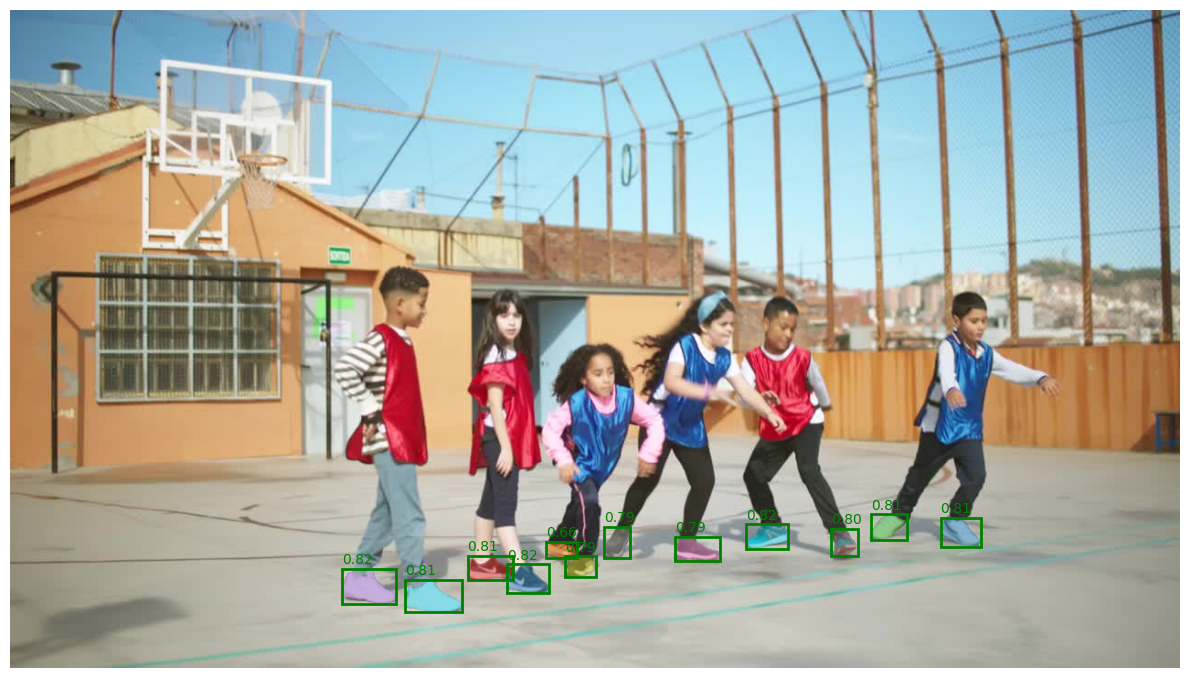

Found 12 object(s) with scores: [0.817477285861969, 0.8109283447265625, 0.6630008816719055, 0.8116924166679382, 0.8081223368644714, 0.8167344331741333, 0.7953609228134155, 0.7920494675636292, 0.7923802733421326, 0.7905803322792053, 0.8153343796730042, 0.8081372976303101]


In [20]:
ov_state = ov_processor.set_image(image)

ov_processor.reset_all_prompts(ov_state)
ov_state = ov_processor.set_text_prompt(prompt="shoe", state=ov_state)

ov_text_masks = ov_state["masks"].clone()
ov_text_scores = ov_state["scores"].clone()

from ov_sam3_helper import show_masks_on_image
show_masks_on_image(
    image, ov_text_masks,
    boxes=ov_state.get("boxes"),
    scores=ov_text_scores,
)
print(f"Found {len(ov_text_masks)} object(s) with scores: {ov_text_scores.tolist()}")

### Single box prompt (OpenVINO)

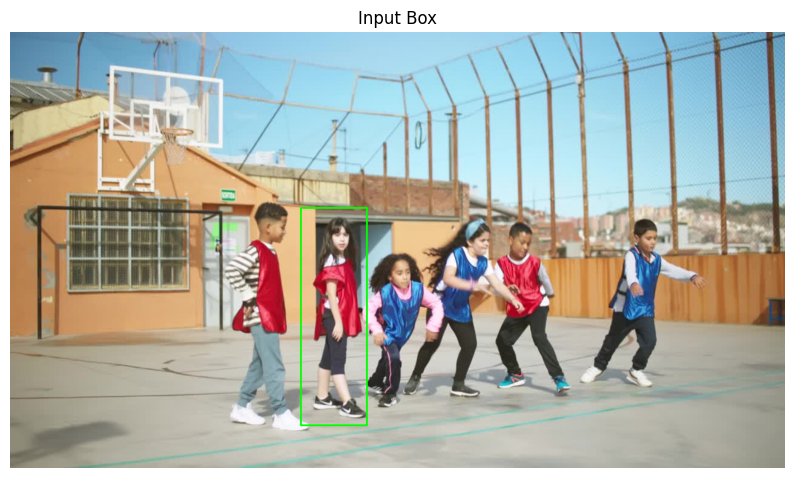

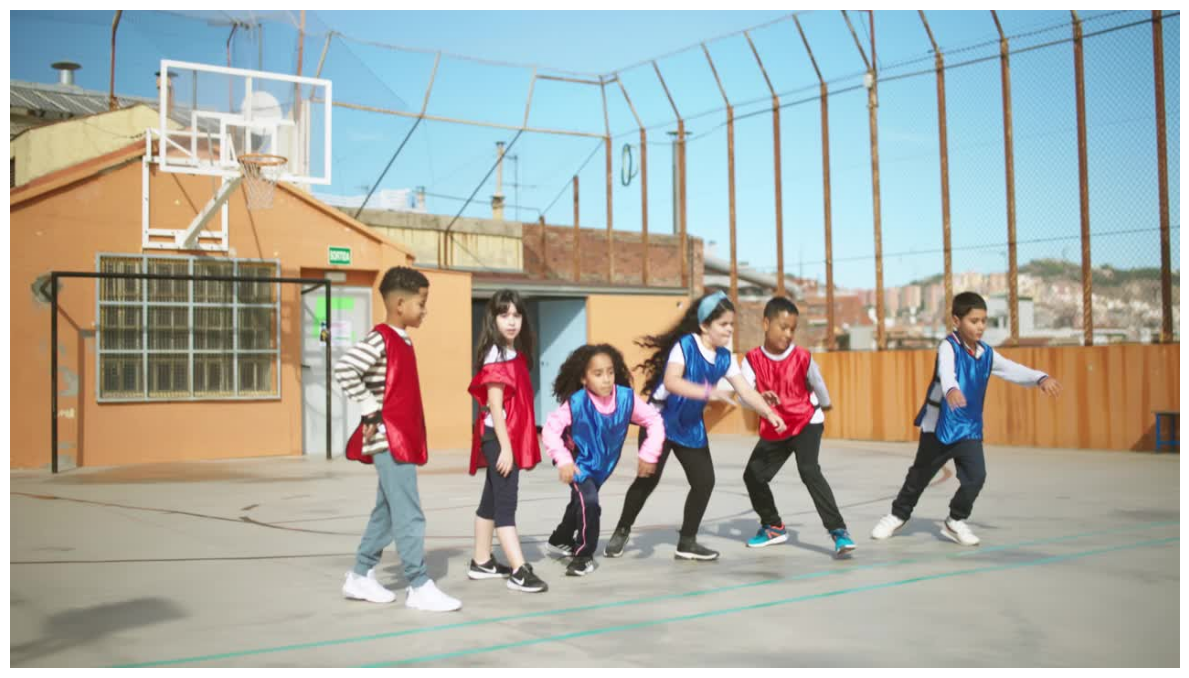

In [21]:
box_input_xywh = torch.tensor([480.0, 290.0, 110.0, 360.0]).view(-1, 4)
box_input_cxcywh = box_xywh_to_cxcywh(box_input_xywh)
norm_box_cxcywh = normalize_bbox(box_input_cxcywh, width, height).flatten().tolist()

ov_processor.reset_all_prompts(ov_state)
ov_state = ov_processor.add_geometric_prompt(
    state=ov_state, box=norm_box_cxcywh, label=True
)

ov_box_masks = ov_state["masks"].clone()

img0 = Image.open(image_path)
image_with_box = draw_box_on_image(img0, box_input_xywh.flatten().tolist())
plt.figure(figsize=(10, 8))
plt.imshow(image_with_box)
plt.axis("off")
plt.title("Input Box")
plt.show()

show_masks_on_image(image, ov_box_masks)

### Multi-box prompting (OpenVINO)

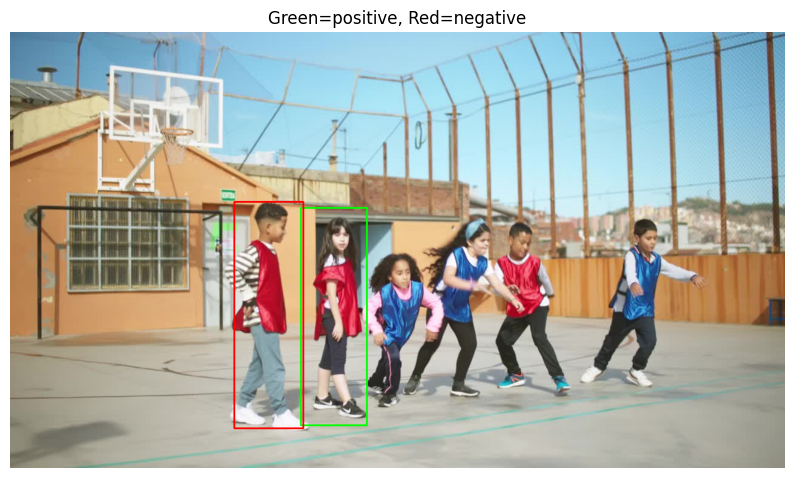

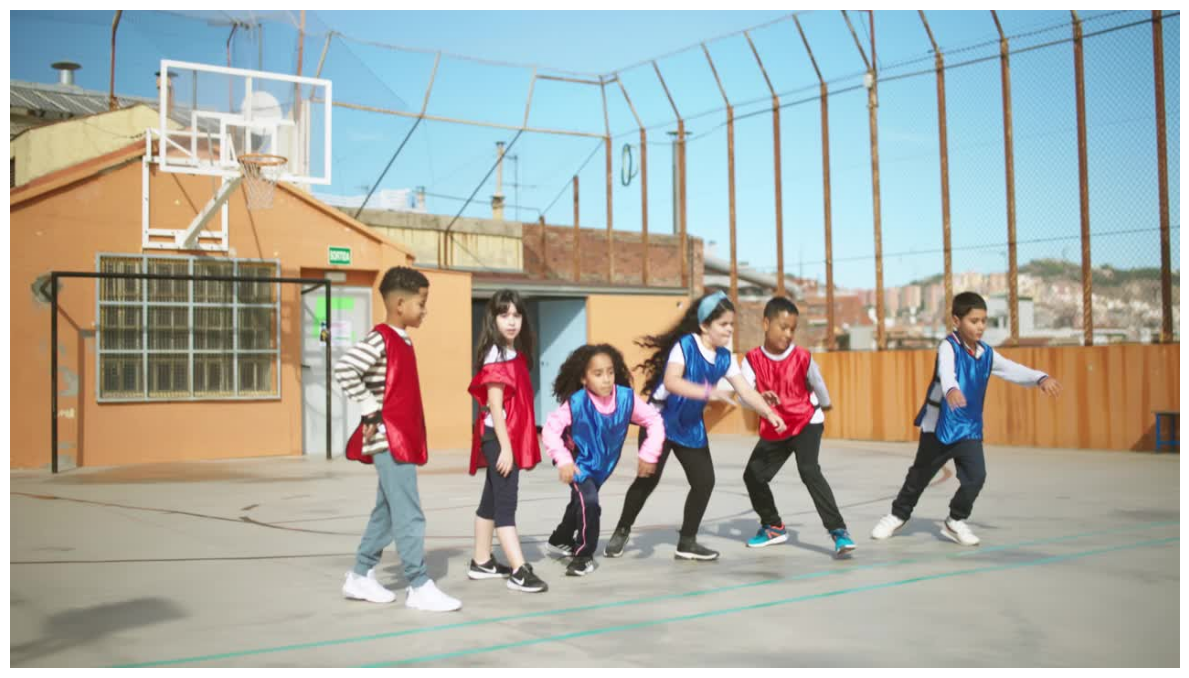

In [22]:
box_input_xywh_list = [[480.0, 290.0, 110.0, 360.0], [370.0, 280.0, 115.0, 375.0]]
box_input_cxcywh = box_xywh_to_cxcywh(torch.tensor(box_input_xywh_list).view(-1, 4))
norm_boxes_cxcywh = normalize_bbox(box_input_cxcywh, width, height).tolist()
box_labels = [True, False]

ov_processor.reset_all_prompts(ov_state)
for box, label in zip(norm_boxes_cxcywh, box_labels):
    ov_state = ov_processor.add_geometric_prompt(
        state=ov_state, box=box, label=label
    )

ov_multibox_masks = ov_state["masks"].clone()

# Visualize
img0 = Image.open(image_path)
for i in range(len(box_input_xywh_list)):
    color = (0, 255, 0) if box_labels[i] else (255, 0, 0)
    img0 = draw_box_on_image(img0, box_input_xywh_list[i], color)
plt.figure(figsize=(10, 8))
plt.imshow(img0)
plt.axis("off")
plt.title("Green=positive, Red=negative")
plt.show()

show_masks_on_image(image, ov_multibox_masks)

### Batched inference (OpenVINO)

Process multiple images with different text prompts.

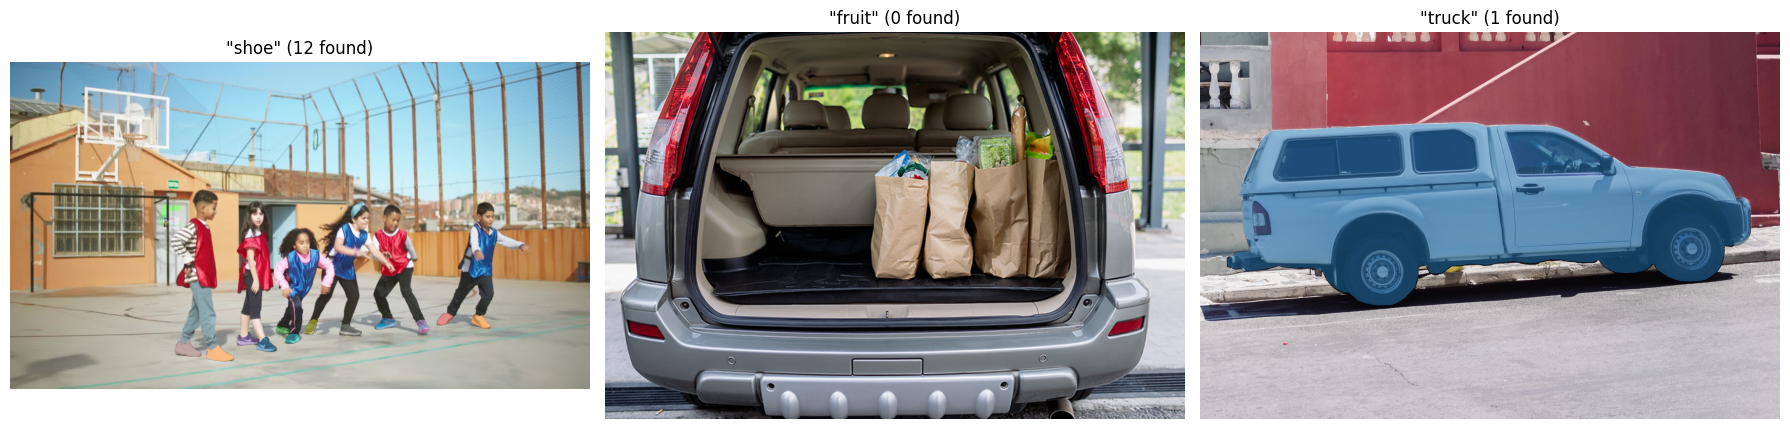

In [23]:
test_images = {
    str(sam3_root / "assets" / "images" / "test_image.jpg"): "shoe",
    str(sam3_root / "assets" / "images" / "groceries.jpg"): "fruit",
    str(sam3_root / "assets" / "images" / "truck.jpg"): "truck",
}

fig, axes = plt.subplots(1, len(test_images), figsize=(6 * len(test_images), 6))
if len(test_images) == 1:
    axes = [axes]

for idx, (img_path, prompt) in enumerate(test_images.items()):
    img = Image.open(img_path)
    batch_state = ov_processor.set_image(img)
    ov_processor.reset_all_prompts(batch_state)
    batch_state = ov_processor.set_text_prompt(prompt=prompt, state=batch_state)

    masks = batch_state.get("masks")
    axes[idx].imshow(img)
    if masks is not None and len(masks) > 0:
        colors = plt.cm.tab10(np.linspace(0, 1, 10))
        for i, mask in enumerate(masks):
            m = mask.cpu().numpy().squeeze()
            colored = np.zeros((*m.shape, 4))
            colored[m > 0.5] = [*colors[i % 10][:3], 0.5]
            axes[idx].imshow(colored)
    n_found = len(masks) if masks is not None else 0
    axes[idx].set_title(f'"{prompt}" ({n_found} found)')
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

## OpenVINO SAM1 Task
[back to top ⬆️](#Table-of-contents:)

SAM3 supports SAM1-style point and box prompting using its built-in SAM2-style interactive predictor.
This uses the SAM2 Prompt Encoder and Mask Decoder models.

In [ ]:
# SAM1 task: all inference uses OV models + extracted frozen weights (no nn.Module at runtime)
if ov_processor._sam1_ready and ov_prompt_encoder is not None and ov_mask_decoder is not None:
    print("SAM1 task ready! Using OV image encoder + OV prompt encoder + OV mask decoder")
    print("  conv_s0/conv_s1/no_mem_embed: extracted as frozen weights (no PyTorch modules)")
else:
    missing = []
    if not ov_processor._sam1_ready:
        missing.append("auxiliary model weights")
    if ov_prompt_encoder is None:
        missing.append("OV prompt encoder")
    if ov_mask_decoder is None:
        missing.append("OV mask decoder")
    print(f"SAM1 task NOT ready. Missing: {', '.join(missing)}")

SAM1 task ready! Using OV image encoder + PT prompt encoder/mask decoder


### Point prompt (foreground)

In [ ]:
if ov_processor._sam1_ready and ov_prompt_encoder is not None:
    # Use OV processor's predict_inst — purely OV inference, no PyTorch modules
    sam1_state = ov_processor.set_image(image)

    # Single foreground point
    input_point = np.array([[535, 470]])
    input_label = np.array([1])

    masks, scores, logits = ov_processor.predict_inst(
        sam1_state,
        point_coords=input_point,
        point_labels=input_label,
        multimask_output=True,
    )

    # Show all masks with scores
    fig, axes = plt.subplots(1, min(3, len(masks)), figsize=(15, 5))
    if len(masks) == 1:
        axes = [axes]
    for i in range(min(3, len(masks))):
        axes[i].imshow(image)
        axes[i].imshow(masks[i].squeeze(), alpha=0.5, cmap="jet")
        axes[i].scatter(*input_point[0], c="green", s=100, marker="*", edgecolors="white", linewidths=1)
        axes[i].set_title(f"Mask {i+1}, Score: {scores[0][i]:.3f}" if scores.ndim > 1 else f"Mask {i+1}, Score: {scores[i]:.3f}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("SAM1 task not available — missing OV prompt encoder/mask decoder or auxiliary weights")

RuntimeError: SAM1 task requires inst_predictor. Pass the full model as auxiliary= instead of the slim auxiliary dict from load_sam3_auxiliary().

### Box prompt (SAM1 task)

In [ ]:
if ov_processor._sam1_ready and ov_prompt_encoder is not None:
    # Box prompt: [x0, y0, x1, y1]
    input_box = np.array([480, 290, 590, 650])

    masks, scores, logits = ov_processor.predict_inst(
        sam1_state,
        box=input_box,
        multimask_output=False,
    )

    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    plt.imshow(masks[0].squeeze(), alpha=0.5, cmap="jet")
    x0, y0, x1, y1 = input_box
    rect = plt.Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=2, edgecolor="green", facecolor="none")
    plt.gca().add_patch(rect)
    plt.axis("off")
    plt.title(f"Box prompt — Score: {scores[0]:.3f}" if scores.ndim == 1 else f"Box prompt — Score: {scores[0][0]:.3f}")
    plt.show()
else:
    print("SAM1 task not available")

### Multiple points (foreground + background)

In [ ]:
if ov_processor._sam1_ready and ov_prompt_encoder is not None:
    # Foreground points (label=1) and background points (label=0)
    input_points = np.array([[535, 470], [400, 400]])
    input_labels = np.array([1, 0])  # 1=foreground, 0=background

    masks, scores, logits = ov_processor.predict_inst(
        sam1_state,
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True,
    )

    # Show best mask
    best_idx = np.argmax(scores.flatten())
    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    plt.imshow(masks[best_idx].squeeze(), alpha=0.5, cmap="jet")
    for pt, lbl in zip(input_points, input_labels):
        color = "green" if lbl == 1 else "red"
        plt.scatter(*pt, c=color, s=100, marker="*", edgecolors="white", linewidths=1)
    plt.axis("off")
    plt.title(f"Best mask — Score: {scores.flatten()[best_idx]:.3f}")
    plt.show()
else:
    print("SAM1 task not available")

## Testing and Verification
[back to top ⬆️](#Table-of-contents:)

Compare PyTorch and OpenVINO outputs to verify conversion correctness.

In [ ]:
from ov_sam3_helper import compare_masks, cosine_similarity

results = []

# Test 1: Text prompt masks comparison
if pt_text_masks.shape == ov_text_masks.shape:
    iou = compare_masks(pt_text_masks, ov_text_masks, title="Text Prompt: PyTorch vs OpenVINO")
    results.append(("Text prompt 'shoe'", f"IoU={iou:.4f}", "PASS" if iou > 0.90 else "FAIL"))
else:
    results.append(("Text prompt 'shoe'", f"Shape mismatch: PT={pt_text_masks.shape} vs OV={ov_text_masks.shape}", "FAIL"))

# Test 2: Box prompt masks comparison
if pt_box_masks.shape == ov_box_masks.shape:
    iou = compare_masks(pt_box_masks, ov_box_masks, title="Box Prompt: PyTorch vs OpenVINO")
    results.append(("Single box prompt", f"IoU={iou:.4f}", "PASS" if iou > 0.90 else "FAIL"))
else:
    results.append(("Single box prompt", f"Shape mismatch: PT={pt_box_masks.shape} vs OV={ov_box_masks.shape}", "FAIL"))

# Test 3: Multi-box masks comparison
if pt_multibox_masks.shape == ov_multibox_masks.shape:
    iou = compare_masks(pt_multibox_masks, ov_multibox_masks, title="Multi-box: PyTorch vs OpenVINO")
    results.append(("Multi-box prompt", f"IoU={iou:.4f}", "PASS" if iou > 0.90 else "FAIL"))
else:
    results.append(("Multi-box prompt", f"Shape mismatch: PT={pt_multibox_masks.shape} vs OV={ov_multibox_masks.shape}", "FAIL"))

In [ ]:
# Test 4: Image encoder unit test
print("\n=== Per-Model Unit Tests ===")

with torch.inference_mode():
    # Prepare test input
    from torchvision.transforms import v2
    transform = v2.Compose([
        v2.ToDtype(torch.uint8, scale=True),
        v2.Resize(size=(1008, 1008)),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ])
    img_tensor = v2.functional.to_image(image)
    test_input = transform(img_tensor).unsqueeze(0)

    # PyTorch image encoder
    pt_result = image_encoder_wrapper(test_input)
    # OV image encoder
    ov_result = ov_image_encoder(test_input.numpy())

    for i in range(len(pt_result)):
        pt_feat = pt_result[i].numpy()
        ov_feat = np.array(ov_result[i])
        sim = cosine_similarity(pt_feat, ov_feat)
        name = f"Image Encoder output {i}"
        status = "PASS" if sim > 0.99 else "FAIL"
        results.append((name, f"cosine_sim={sim:.6f}", status))
        print(f"  {name}: cosine_sim={sim:.6f} [{status}]")

In [ ]:
# Print summary
print("\n" + "=" * 60)
print("VERIFICATION SUMMARY")
print("=" * 60)
print(f"{'Test':<35} {'Metric':<25} {'Status'}")
print("-" * 60)
for test_name, metric, status in results:
    marker = "✓" if status == "PASS" else "✗"
    print(f"{marker} {test_name:<33} {metric:<25} {status}")

n_pass = sum(1 for _, _, s in results if s == "PASS")
n_total = len(results)
print(f"\nOverall: {n_pass}/{n_total} tests passed")

## Performance Comparison
[back to top ⬆️](#Table-of-contents:)

Compare inference latency between PyTorch (CPU) and OpenVINO.

In [ ]:
import time

# Warm up
_ = ov_processor.set_image(image)

# Benchmark OV image encoder
n_runs = 3
ov_times = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    _ = ov_processor.set_image(image)
    ov_times.append(time.perf_counter() - t0)

# Benchmark PyTorch image encoder
pt_times = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    _ = processor.set_image(image)
    pt_times.append(time.perf_counter() - t0)

ov_avg = np.mean(ov_times)
pt_avg = np.mean(pt_times)

print(f"Image Encoding Latency ({n_runs} runs average):")
print(f"  PyTorch (CPU):  {pt_avg:.3f}s")
print(f"  OpenVINO ({device.value}): {ov_avg:.3f}s")
print(f"  Speedup: {pt_avg / ov_avg:.2f}x")

In [ ]:
# Full pipeline benchmark (text prompt)
ov_full_times = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    s = ov_processor.set_image(image)
    ov_processor.reset_all_prompts(s)
    s = ov_processor.set_text_prompt(prompt="shoe", state=s)
    ov_full_times.append(time.perf_counter() - t0)

pt_full_times = []
pt_proc = Sam3Processor(model, device="cpu", confidence_threshold=0.5)
for _ in range(n_runs):
    t0 = time.perf_counter()
    s = pt_proc.set_image(image)
    pt_proc.reset_all_prompts(s)
    s = pt_proc.set_text_prompt(state=s, prompt="shoe")
    pt_full_times.append(time.perf_counter() - t0)

ov_full_avg = np.mean(ov_full_times)
pt_full_avg = np.mean(pt_full_times)

print(f"\nFull Pipeline Latency (text prompt, {n_runs} runs average):")
print(f"  PyTorch (CPU):  {pt_full_avg:.3f}s")
print(f"  OpenVINO ({device.value}): {ov_full_avg:.3f}s")
print(f"  Speedup: {pt_full_avg / ov_full_avg:.2f}x")

In [ ]:
# Model size comparison
ov_model_files = list(ov_model_dir.glob("*.bin"))
total_ov_size = sum(f.stat().st_size for f in ov_model_files)

ckpt_path = Path("sam3_model") / "sam3.pt"
pt_size = ckpt_path.stat().st_size if ckpt_path.exists() else 0

print(f"\nModel Size Comparison:")
print(f"  PyTorch checkpoint: {pt_size / 1e9:.2f} GB")
print(f"  OpenVINO IR total:  {total_ov_size / 1e9:.2f} GB")
print(f"\nIndividual OV model sizes:")
for f in sorted(ov_model_dir.glob("*.bin")):
    print(f"  {f.stem}: {f.stat().st_size / 1e6:.1f} MB")

## Interactive Demo
[back to top ⬆️](#Table-of-contents:)

Use the interactive Gradio demo below to try SAM3 with your own images. You can:
- Upload an image and enter a text prompt to segment objects
- Draw bounding boxes to specify regions of interest
- Click points for SAM1-style foreground/background prompting

In [ ]:
import gradio as gr
import numpy as np
import torch
from PIL import Image


def segment_text(image, text_prompt, confidence):
    """Segment objects by text prompt."""
    if image is None or not text_prompt.strip():
        return None
    pil_image = Image.fromarray(image) if isinstance(image, np.ndarray) else image
    state = ov_processor.set_image(pil_image)
    ov_processor.confidence_threshold = confidence
    ov_processor.reset_all_prompts(state)
    state = ov_processor.set_text_prompt(prompt=text_prompt, state=state)
    masks = state.get("masks")
    scores = state.get("scores")
    if masks is None or len(masks) == 0:
        return image
    return _overlay_masks(image, masks, scores)


def segment_point(image, point_type, evt: gr.SelectData):
    """Segment by clicking a point on the image."""
    if image is None:
        return image
    x, y = evt.index
    pil_image = Image.fromarray(image) if isinstance(image, np.ndarray) else image
    state = ov_processor.set_image(pil_image)
    label = 1 if point_type == "Foreground" else 0
    masks, scores, _ = ov_processor.predict_inst(
        state,
        point_coords=np.array([[x, y]]),
        point_labels=np.array([label]),
        multimask_output=True,
    )
    best_idx = np.argmax(scores.flatten())
    mask = masks[best_idx]
    return _overlay_single_mask(image, mask)


def segment_box(image, box_input):
    """Segment by bounding box [x0, y0, x1, y1]."""
    if image is None or not box_input.strip():
        return image
    try:
        coords = [float(x.strip()) for x in box_input.split(",")]
        assert len(coords) == 4
    except Exception:
        return image
    pil_image = Image.fromarray(image) if isinstance(image, np.ndarray) else image
    state = ov_processor.set_image(pil_image)
    input_box = np.array(coords)
    masks, scores, _ = ov_processor.predict_inst(
        state,
        box=input_box,
        multimask_output=False,
    )
    return _overlay_single_mask(image, masks[0])


def _overlay_masks(image, masks, scores=None):
    """Overlay multiple masks on image with different colors."""
    import matplotlib.cm as cm
    img = np.array(image).copy() if not isinstance(image, np.ndarray) else image.copy()
    colors = cm.tab10(np.linspace(0, 1, 10))[:, :3]
    for i, mask in enumerate(masks):
        m = mask.cpu().numpy().squeeze() if isinstance(mask, torch.Tensor) else np.squeeze(mask)
        color = (colors[i % len(colors)] * 255).astype(np.uint8)
        img[m > 0.5] = img[m > 0.5] * 0.5 + color * 0.5
    return img


def _overlay_single_mask(image, mask, color=(30, 144, 255)):
    """Overlay a single mask on image."""
    img = np.array(image).copy() if not isinstance(image, np.ndarray) else image.copy()
    m = mask.squeeze()
    if isinstance(m, torch.Tensor):
        m = m.cpu().numpy()
    color = np.array(color, dtype=np.uint8)
    img[m > 0.5] = (img[m > 0.5] * 0.5 + color * 0.5).astype(np.uint8)
    return img


with gr.Blocks(title="SAM3 OpenVINO Demo") as demo:
    gr.Markdown("# SAM 3 Segmentation with OpenVINO")
    with gr.Tabs():
        with gr.TabItem("Text Prompt"):
            with gr.Row():
                with gr.Column():
                    text_image = gr.Image(label="Input Image", type="numpy")
                    text_input = gr.Textbox(label="Text Prompt", placeholder="e.g. shoe, person, car...")
                    confidence = gr.Slider(0.1, 0.9, value=0.5, step=0.05, label="Confidence Threshold")
                    text_btn = gr.Button("Segment", variant="primary")
                with gr.Column():
                    text_output = gr.Image(label="Result")
            text_btn.click(segment_text, [text_image, text_input, confidence], text_output)

        with gr.TabItem("Point Prompt (SAM1)"):
            with gr.Row():
                with gr.Column():
                    point_image = gr.Image(label="Click on image to segment", type="numpy")
                    point_type = gr.Radio(["Foreground", "Background"], value="Foreground", label="Point Type")
                with gr.Column():
                    point_output = gr.Image(label="Result")
            point_image.select(segment_point, [point_image, point_type], point_output)

        with gr.TabItem("Box Prompt (SAM1)"):
            with gr.Row():
                with gr.Column():
                    box_image = gr.Image(label="Input Image", type="numpy")
                    box_input = gr.Textbox(label="Box coordinates (x0, y0, x1, y1)", placeholder="480, 290, 590, 650")
                    box_btn = gr.Button("Segment", variant="primary")
                with gr.Column():
                    box_output = gr.Image(label="Result")
            box_btn.click(segment_box, [box_image, box_input], box_output)

try:
    demo.launch(debug=True)
except Exception:
    demo.launch(debug=True, share=True)